<hr style="height:.9px;border:none;color:#333;background-color:#333;" />
<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<br><h1>Astrophotographic Post-Capture Alignment</h1>
<h4>An Earth-Based Computer Vision Approach to Aligning Lunar Frames</h4>
Chase Kusterer<br>
Northwestern University<br><br><br>

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />
<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>Problem Statement</h2>

A common approach to amateur astrophotography is to utilize a consumer-grade telescope as the lens for a professional camera. However, consumer-grade telescopes frequently suffer from severe image degradation caused by equipment jitter and atmospheric turbulence. While hardware solutions such as equatorial tracking mounts can mitigate physical instability, they remain financially prohibitive and cannot overcome the challenge of atmospheric blur caused by shifting air currents. Additionally, standard consumer computational photography frameworks are optimized for daytime landscapes and faces, failing to resolve high-contrast, distant astronomical structures like planetary bands or lunar craters.
<br><br>
Atmospheric blur can be alleviated with lucky imaging, an astrophotography technique that records hundreds to thousands of short-exposure video frames and stacks the sharpest "lucky" frames into a composite image. Lucky imaging requires the object of interest to be highly aligned across video frames, which is an incredible challenge. This project introduces an alignment solution for the Moon using modern computer vision techniques.
<br><br>

<h3>Computer Vision Techniques</h3>

* Segment Anything Model (SAM)
* Laplacian-of-Gaussian Blob Detection (LoG)
* RANSAC Circle Fitting
* Centriod-Based Alignment

<br>
<h3>Architecture</h3>

~~~

  REFERENCE BUILD (once)              TEST FRAME (per capture)
  --------------------------          --------------------------
  Reference Inputs                    Raw Capture
   Robbins Catalog (.csv)              Sony A7 IV (.ARW)
   + LROC mosaic (.tif)                     |
        |                                   v
        v                             Preprocess
  Coordinate Reference System          16-bit, average to 1
   Orthographic Disk Fit,              channel, rotate upright
   km/pixel scale                            \
        |                                      \
        v                                       \
  Crater Reference Mask                          \
   8 Maria Projected, 295 Craters                 \
        \                                          /
         \________________________________________/
                              |
                              v
              Binary Segmentation (SAM vit_b)
               clean mask: largest blob, fill holes
                              |
                              v
              RANSAC Limb-Circle Fit
               3-point solve, inlier voting
                              |
                              v
              Scale + Translate
               warp test onto 1200 x 1200 canvas
                              |
                              v
              Maximize Disk Overlap
               translation search, IoU
                              |
                              v
              LoG Crater Detection
               blob_log on test, centroid referenced
                              |
                              v
              Optuna Tuning
               4 controls, maximize DICE, 500 trials
                              |
                              v
              Manual False-Positive Review
               drop flagged craters, rebuild mask
                              |
                              v
              Crater Match + Rotation Search
               fine tuning
~~~

<br>

<h3>Limitations</h3>

Results should be interpreted with respect to the following limitations.

1. The coordinate reference system (CRS) that was developed and utilized in this analysis has been modeled as a flat disk with the Moon's sub-Earth point (i.e., the central point of the near side of the Moon) as the origin. Accuracy is high for coordinates near the sub-Earth point, but it degrades close to the limb (i.e., the circular edge of the near side of the Moon). To alleviate this, CRS scope has been limited to eight central and highly visible maria (i.e., vast planes of solidified basaltic lava once thought to be seas).
2. The test frame was captured while the Moon was in a waning gibbous phase at 59% illumination. Results may vary for frames captured during other phases and illumination levels.

<br>
<hr style="height:.9px;border:none;color:#333;background-color:#333;" />
<h2>Imports and Configuration</h2>

In [22]:
# package installs
%pip install segment_anything optuna rawpy tifffile opencv-python

<br>

In [23]:
# core numerics, tables, and math
import os
import numpy as np
import pandas as pd
import math
import urllib.request

# raw decoding and blob detection
import rawpy
from skimage.feature import blob_log
from scipy.ndimage import binary_fill_holes, label

# hyperparameter search
import optuna

# reference raster and image ops
import tifffile as tiff
import cv2

# SAM
import torch
from segment_anything import SamPredictor, sam_model_registry

# display and housekeeping
import matplotlib.pyplot as plt
import warnings


# quiet warnings and a reproducible seed
warnings.filterwarnings('ignore')

random_seed = 702
np.random.seed(random_seed)


print(f"""
Environment
-----------

Seed: {random_seed}
""")


Environment
-----------

Seed: 702



<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

The coordinate reference system (CRS) was developed by mapping a mosaic of 1,300 nearside wide angle images captured from the Lunar Reconnaissance Orbiter Camera to the <a href="https://www.kaggle.com/datasets/sujaykapadnis/moon-crater-database-v1-robbins/data">Robbins Lunar Crater Database</a>. This resulted in a surface radius of 7800 pixels at a scale of 0.223 kilometers per pixel.

In [24]:
# path to the robbins 2018 catalog in the working directory
robbins_path = './lunar_crater_database_robbins_2018.csv'


# reading the circle-fit centre and diameter, then wrapping longitude to -180..180 east
robbins = pd.read_csv(filepath_or_buffer = robbins_path,
                      usecols = ['LAT_CIRC_IMG', 'LON_CIRC_IMG', 'DIAM_CIRC_IMG'])

robbins = robbins.rename(columns = {'LAT_CIRC_IMG'  : 'lat',
                                    'LON_CIRC_IMG'  : 'lon',
                                    'DIAM_CIRC_IMG' : 'diam_km'})

robbins['lon'] = ((robbins['lon'] + 180) % 360) - 180


# loading the reference and fitting its disk from the row and column profiles
lroc_ref = tiff.imread('reference_image_nearside_moon.tif')

h_ref, w_ref = lroc_ref.shape[:2]

lit_cols = np.where(lroc_ref.max(axis = 0) > 20)[0]
lit_rows = np.where(lroc_ref.max(axis = 1) > 20)[0]

ref_cx = (lit_cols.min() + lit_cols.max()) / 2.0
ref_cy = (lit_rows.min() + lit_rows.max()) / 2.0
ref_R  = (lit_cols.max() - lit_cols.min()) / 2.0


# kilometres per pixel from the lunar radius, used later for crater sizes
moon_radius_km = 1737.4
km_per_px      = moon_radius_km / ref_R


# a geometric disk from the fit, this bounds valid pixels and trims limb spill
disk_mask = np.zeros((h_ref, w_ref), dtype = np.uint8)
cv2.circle(img       = disk_mask,
           center    = (int(ref_cx), int(ref_cy)),
           radius    = int(ref_R),
           color     = 1,
           thickness = -1)


# forward orthographic, latitude and longitude to a reference pixel
def latlon_to_ortho_px(lat_deg, lon_deg):
    """Maps selenographic latitude and longitude to a reference pixel.

    PARAMETERS
    ----------
    lat_deg | float
    centre latitude in degrees north

    lon_deg | float
    centre longitude in degrees east, -180..180

    EXAMPLES
    --------
    latlon_to_ortho_px(lat_deg = 9.62, lon_deg = -20.07)\
    """

    lat = np.radians(lat_deg)
    lon = np.radians(lon_deg)

    x = ref_R * np.cos(lat) * np.sin(lon)
    y = ref_R * np.sin(lat)

    return ref_cx + x, ref_cy - y


# inverse orthographic, a reference pixel back to latitude and longitude
def ortho_px_to_latlon(u, v):
    """Maps a reference pixel to selenographic latitude and longitude.

    PARAMETERS
    ----------
    u | float
    pixel column on the reference disk

    v | float
    pixel row on the reference disk

    EXAMPLES
    --------
    ortho_px_to_latlon(u = 5159, v = 6497)\
    """

    x = u - ref_cx
    y = ref_cy - v

    lat = np.degrees(np.arcsin(y / ref_R))
    lon = np.degrees(np.arctan2(x, np.sqrt(ref_R**2 - x**2 - y**2)))

    return lat, lon


print(f"""
Coordinate System
-----------------
reference : {w_ref} by {h_ref} px
disk cx cy: ({ref_cx:.0f}, {ref_cy:.0f})
disk radius: {ref_R:.0f} px
scale     : {km_per_px:.3f} km per pixel
""")


Coordinate System
-----------------
reference : 15600 by 15600 px
disk cx cy: (7800, 7800)
disk radius: 7800 px
scale     : 0.223 km per pixel



<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>Crater Reference Mask Development</h2>

Although the Robbins Lunar Crater Database contains approximately 1.3 million lunar impact craters, the scope of crater detection was reduced to the boundaries of eight maria on the near side of the Moon. This was to ensure craters were being detected at highly stable areas of the CRS. A total of 295 craters were present within the coordinates listed below, covering 3.8% of the reference frame.
<br><br>

<table>
<tr><th align="left">Mare (Sea)</th><th align="left">latitude</th><th align="left">longitude (east)</th></tr>
<tr><td>Mare Imbrium</td><td>15 to 55</td><td>-40 to 5</td></tr>
<tr><td>Mare Serenitatis</td><td>15 to 42</td><td>5 to 32</td></tr>
<tr><td>Mare Tranquillitatis</td><td>-6 to 22</td><td>17 to 46</td></tr>
<tr><td>Mare Vaporum</td><td>6 to 20</td><td>-3 to 12</td></tr>
<tr><td>Mare Nectaris</td><td>-25 to -6</td><td>26 to 42</td></tr>
<tr><td>Mare Crisium</td><td>8 to 27</td><td>48 to 72</td></tr>
<tr><td>Mare Fecunditatis</td><td>-18 to 4</td><td>40 to 63</td></tr>
<tr><td>Imbrium to Humorum</td><td>-18 to 15</td><td>-40 to 5</td></tr>
</table>
<br>

In [25]:
# bounding boxes per sea, as (lat_min, lat_max, lon_min, lon_max) in degrees, lon east -180..180
maria = {'imbrium'            : ( 15, 55, -40,   5),
         'serenitatis'        : ( 15, 42,   5,  32),
         'tranquillitatis'    : ( -6, 22,  17,  46),
         'vaporum'            : (  6, 20,  -3,  12),
         'nectaris'           : (-25, -6,  26,  42),
         'crisium'            : (  8, 27,  48,  72),
         'fecunditatis'       : (-18,  4,  40,  63),
         'imbrium_to_humorum' : (-18, 15, -40,   5)}


# size band and a generous near-side emission guard
min_diam_km      = 20.0
max_diam_km      = 304.0
max_emission_deg = 80.0


# flagging craters that fall inside any mare box
in_box = np.zeros(len(robbins), dtype = bool)

for lat_lo, lat_hi, lon_lo, lon_hi in maria.values():
    in_box |= ((robbins['lat'] >= lat_lo) & (robbins['lat'] <= lat_hi) &
               (robbins['lon'] >= lon_lo) & (robbins['lon'] <= lon_hi)).values


# emission angle from the sub-earth point, then the combined selection
emission = np.degrees(np.arccos(np.cos(np.radians(robbins['lat'])) *
                                np.cos(np.radians(robbins['lon']))))

visible = robbins[in_box                                 &
                  (emission.values < max_emission_deg)   &
                  (robbins['diam_km'] >= min_diam_km)     &
                  (robbins['diam_km'] <= max_diam_km)].copy()


# projecting every kept crater and painting it as a filled circle
u_px, v_px = latlon_to_ortho_px(lat_deg = visible['lat'].values,
                                lon_deg = visible['lon'].values)

radius_px = np.maximum(1, (visible['diam_km'].values / 2.0) / km_per_px).astype(int)

reference_crater_mask = np.zeros((h_ref, w_ref), dtype = np.uint8)

for u_c, v_c, r_c in zip(u_px.astype(int), v_px.astype(int), radius_px):
    cv2.circle(img       = reference_crater_mask,
               center    = (int(u_c), int(v_c)),
               radius    = int(r_c),
               color     = 1,
               thickness = -1)


# keeping the mask on the disk
reference_crater_mask = (reference_crater_mask & disk_mask).astype(np.uint8)


print(f"""
reference_crater_mask
---------------------
Bounding Boxes : {len(maria)}
Craters Drawn  : {len(visible):,}
Coverage       : {reference_crater_mask.mean():.2%} of the frame
""")


reference_crater_mask
---------------------
Bounding Boxes : 8
Craters Drawn  : 295
Coverage       : 3.80% of the frame



<br>

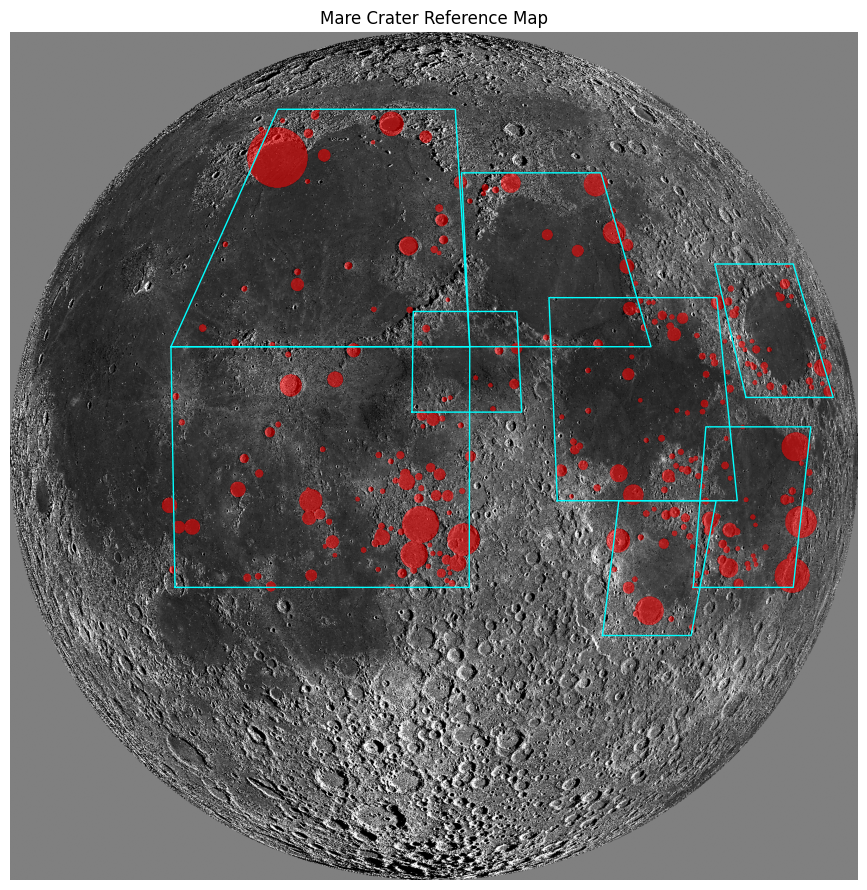

In [26]:
# downsampling for a light figure, the full mask stays in reference_crater_mask
ds = 10

ref_small  = lroc_ref[::ds, ::ds]
mask_small = reference_crater_mask[::ds, ::ds]


# overlaying the mask and the mare boxes, then saving
plt.figure(figsize = (9, 9))
plt.imshow(ref_small, cmap = 'gray')
plt.imshow(np.ma.masked_where(mask_small == 0, mask_small), cmap = 'autumn', alpha = 0.55)

for lat_lo, lat_hi, lon_lo, lon_hi in maria.values():
    edge_lat = np.array([lat_lo, lat_lo, lat_hi, lat_hi, lat_lo])
    edge_lon = np.array([lon_lo, lon_hi, lon_hi, lon_lo, lon_lo])
    bx, by   = latlon_to_ortho_px(lat_deg = edge_lat, lon_deg = edge_lon)
    plt.plot(bx / ds, by / ds, '-', color = 'cyan', linewidth = 1)

plt.title('Mare Crater Reference Map')
plt.axis('off')
plt.tight_layout()

plt.savefig('crater_reference_map.png', dpi = 120)
plt.show()

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>Test Frame Preprocessing</h2>

The test frame utilized below was captured with a Sony Alpha 7 IV camera, which natively stores images in ARW format. It was preprocessed to a 16-bit TIF where its three color channels were averaged into one. Additionally, as the test frame was in landscape format, it was rotated 90 degrees clockwise for better orientation with the crater reference mask.

In [27]:
# path to the raw test frame, working directory for now
test_path = 'DSC02028.ARW'
# test_path = '/images/DSC02028.ARW'   # read from the images folder instead


# demosaicing the raw to 16-bit and reducing to one channel
moon_rgb16 = rawpy.imread(test_path).postprocess(output_bps     = 16,
                                                      no_auto_bright = True,
                                                      use_camera_wb  = True,
                                                      gamma          = (1, 1))

moon_raw = moon_rgb16.mean(axis = 2).astype(np.float32)


# rotating a landscape frame a quarter turn clockwise to stand the moon upright
if moon_raw.shape[1] > 1.2 * moon_raw.shape[0]:
    moon_raw = cv2.rotate(moon_raw, cv2.ROTATE_90_CLOCKWISE)


print(f"""
Test Frame
----------
shape : {moon_raw.shape[0]} by {moon_raw.shape[1]} px
""")


Test Frame
----------
shape : 7028 by 4688 px



<br>

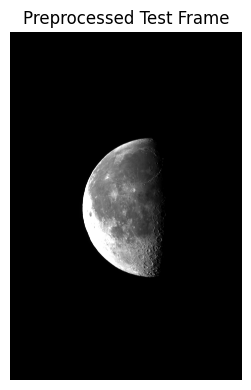

In [28]:
# stretching the linear frame to a visible range using robust percentiles
lo, hi    = np.percentile(moon_raw, q = (1, 99))
moon_disp = np.clip((moon_raw - lo) / (hi - lo), a_min = 0, a_max = 1)


# showing the upright moon in grayscale
plt.figure(figsize = (3, 4))
plt.imshow(moon_disp, cmap = 'gray')
plt.axis('off')
plt.title(label = 'Preprocessed Test Frame')
plt.tight_layout()
plt.savefig("preprocessed_test_frame.png")
plt.show()

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>Binary Segmentation With SAM</h2>

Binary segmentation was conducted on the test and reference images to separate the Moon from the surrounding dark sky. The base Segment Anything Model (SAM) performed exceptionally well due to the intense contrast between the object of interest and its background. This model, <code>vit_b</code>, contains approximately 91 million parameters, making it the smallest and fastest of Meta's SAM models. During development, <code>vit_b</code> would occasionally over segment the reference image, correctly masking the circular shape of the Moon but leaving a few pinholes on the disk body. To mitigate the risk of over segmentation, a post-segmentation step was implemented to clean each mask by identifying its largest piece and filling any interior holes.
<br><br>

In [29]:
# downloading the sam vit-b weights on first run
checkpoint_path = 'sam_vit_b_01ec64.pth'

if not os.path.exists(checkpoint_path):
    weights_url = 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth'
    urllib.request.urlretrieve(url = weights_url, filename = checkpoint_path)


# loading sam onto the gpu as a predictor
device    = 'cuda'
sam       = sam_model_registry['vit_b'](checkpoint = checkpoint_path)
sam.to(device = device)
predictor = SamPredictor(sam)


def segment_moon_sam(gray, point_xy = None, box_xyxy = None):
    """Segments the lit moon body from a point prompt or a box prompt.

    PARAMETERS
    ----------
    gray | np.ndarray
    single-channel image of the moon on dark sky

    point_xy | tuple
    an (x, y) pixel on the lit disk, or None

    box_xyxy | tuple
    an (x0, y0, x1, y1) box around the disk, or None

    EXAMPLES
    --------
    segment_moon_sam(gray = moon_raw, point_xy = (1800, 1100))\
    """

    h, w      = gray.shape[:2]
    scale     = 1024 / w
    small_rgb = cv2.resize(src   = np.stack([((gray / np.percentile(gray, 99.9)) * 255.0).clip(0, 255).astype(np.uint8)] * 3, axis = -1),
                           dsize = (1024, int(h * scale)))

    point_coords = None
    point_labels = None
    box          = None

    if point_xy is not None:
        point_coords = np.array([[int(point_xy[0] * scale), int(point_xy[1] * scale)]])
        point_labels = np.array([1])

    if box_xyxy is not None:
        box = np.array([box_xyxy[0] * scale, box_xyxy[1] * scale,
                        box_xyxy[2] * scale, box_xyxy[3] * scale])

    with torch.inference_mode(), torch.cuda.amp.autocast():
        predictor.set_image(small_rgb)
        masks, scores, _ = predictor.predict(point_coords     = point_coords,
                                             point_labels     = point_labels,
                                             box              = box,
                                             multimask_output = False)

    return cv2.resize(src           = masks[0].astype(np.uint8),
                      dsize         = (w, h),
                      interpolation = cv2.INTER_NEAREST)


# keeping only the largest blob and filling interior holes, to drop specks
def clean_mask(mask):
    """returns the largest connected region of a binary mask with holes filled

    PARAMETERS
    ----------
    mask | np.ndarray
    binary mask that may carry specks or pinholes

    EXAMPLES
    --------
    clean_mask(mask = ref_moon_mask)\
    """

    binary = (mask > 0).astype(np.uint8)

    labelled, count = label(binary)
    if count == 0:
        return binary

    sizes    = np.bincount(labelled.ravel())
    sizes[0] = 0
    largest  = (labelled == sizes.argmax()).astype(np.uint8)

    return binary_fill_holes(largest).astype(np.uint8)


# segmenting then cleaning each moon
bright_ys, bright_xs = np.where(moon_raw > np.percentile(moon_raw, 99))
test_point           = (bright_xs.mean(), bright_ys.mean())

test_moon_mask = clean_mask(segment_moon_sam(gray = moon_raw, point_xy = test_point))

ref_box       = (ref_cx - ref_R, ref_cy - ref_R, ref_cx + ref_R, ref_cy + ref_R)
ref_moon_mask = segment_moon_sam(gray = lroc_ref, box_xyxy = ref_box)

if ref_moon_mask.mean() < 0.30:
    ref_moon_mask = disk_mask.copy()

ref_moon_mask = clean_mask(ref_moon_mask)


print(f"""
Moon Segments
-------------
test lit  : {test_moon_mask.mean():.1%} of its frame
reference : {ref_moon_mask.mean():.1%} of its frame
""")


Moon Segments
-------------
test lit  : 10.9% of its frame
reference : 77.4% of its frame



<br>

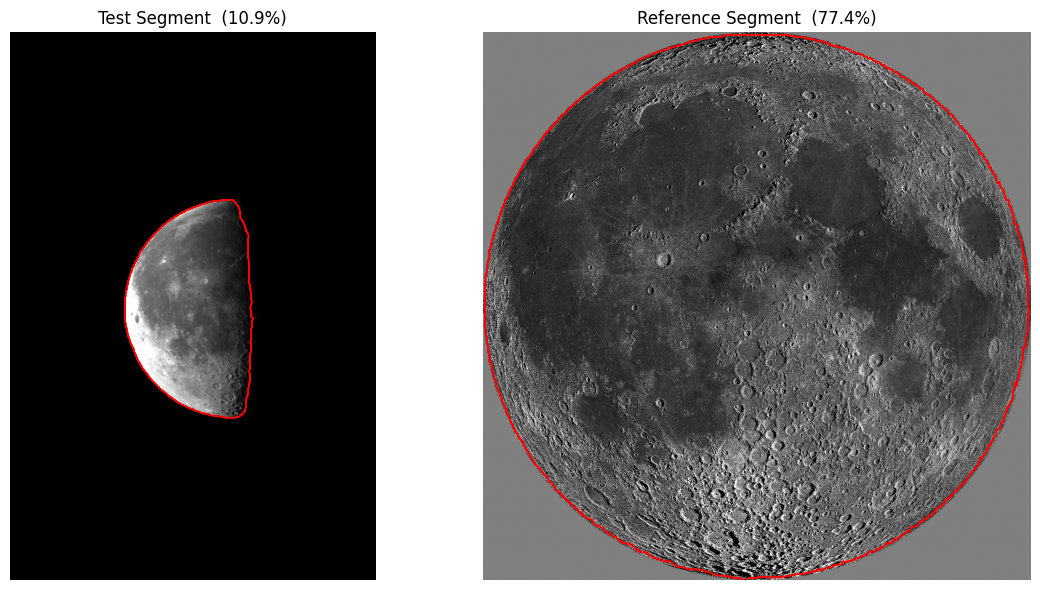

In [30]:
# a quick look at both moon segments
fig, ax = plt.subplots(1, 2, figsize = (12, 6))

ax[0].imshow(moon_raw[::4, ::4], cmap = 'gray', vmax = np.percentile(moon_raw, 99.5))
ax[0].contour(test_moon_mask[::4, ::4], colors = 'red', linewidths = 0.8)
ax[0].set_title(f'Test Segment  ({test_moon_mask.mean():.1%})')
ax[0].axis('off')

ax[1].imshow(lroc_ref[::10, ::10], cmap = 'gray')
ax[1].contour(ref_moon_mask[::10, ::10], colors = 'red', linewidths = 0.8)
ax[1].set_title(f'Reference Segment  ({ref_moon_mask.mean():.1%})')
ax[1].axis('off')

plt.tight_layout()
plt.show()

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>RANSAC Circle Fitting</h2>

The circular shape of the outer limb in both segments was estimated with Random Sample Consensus (RANSAC). For each segment, three boundary points were sampled and solved into circles, and the circle the most points agreed with was retained. This helped the RANSAC algorithm ignore points along the terminator, the dividing line that separates the bright and dark portions of the moon. The resulting radius of the RANSAC circle in the reference image was 7,744 pixels, 99.28% the length of the surface radius of the CRS, indicating that the approach was successful. The images can now be scaled to the same size.

In [31]:
# exact circle through three points
def solve_three_point_circle(p1, p2, p3):
    """Returns the centre and radius of the circle through three points.

    PARAMETERS
    ----------
    p1, p2, p3 | tuple
    (x, y) boundary points

    EXAMPLES
    --------
    solve_three_point_circle((0, 0), (1, 0), (0, 1))\
    """

    ax, ay = p1
    bx, by = p2
    cx, cy = p3

    d = 2 * (ax * (by - cy) + bx * (cy - ay) + cx * (ay - by))
    if abs(d) < 1e-6:
        return None

    ux = ((ax**2 + ay**2) * (by - cy) + (bx**2 + by**2) * (cy - ay) + (cx**2 + cy**2) * (ay - by)) / d
    uy = ((ax**2 + ay**2) * (cx - bx) + (bx**2 + by**2) * (ax - cx) + (cx**2 + cy**2) * (bx - ax)) / d

    return ux, uy, math.hypot(ax - ux, ay - uy)


# ransac limb fit on a binary segment
def fit_limb_circle(mask, iterations = 3000, tolerance = 3.0):
    """Fits the full-disk limb circle to a moon segment.

    PARAMETERS
    ----------
    mask | np.ndarray
    binary moon segment

    iterations | int
    number of random three-point trials

    tolerance | float
    inlier band in pixels

    EXAMPLES
    --------
    fit_limb_circle(mask = test_moon_mask)\
    """

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    points      = max(contours, key = cv2.contourArea).reshape(-1, 2).astype(np.float64)

    best_circle  = (0.0, 0.0, 0.0)
    best_inliers = 0

    for _ in range(iterations):
        idx    = np.random.choice(len(points), 3, replace = False)
        result = solve_three_point_circle(points[idx[0]], points[idx[1]], points[idx[2]])
        if result is None:
            continue

        c_x, c_y, rad = result
        if rad <= 0 or rad > max(mask.shape):
            continue

        offsets = np.abs(np.hypot(points[:, 0] - c_x, points[:, 1] - c_y) - rad)
        inliers = int((offsets < tolerance).sum())

        if inliers > best_inliers:
            best_inliers = inliers
            best_circle  = result

    return best_circle, best_inliers


# fitting the limb in both images
np.random.seed(random_seed)

test_circle, test_inliers = fit_limb_circle(mask = test_moon_mask)
ref_circle,  ref_inliers  = fit_limb_circle(mask = ref_moon_mask)


print(f"""
Limb Circles
------------
Test      : Center ({test_circle[0]:.0f}, {test_circle[1]:.0f})  Radius {test_circle[2]:.0f} px  Inliers {test_inliers}
Reference : Center ({ref_circle[0]:.0f}, {ref_circle[1]:.0f})  Radius {ref_circle[2]:.0f} px  Inliers {ref_inliers}
""")


Limb Circles
------------
Test      : Center (2872, 3543)  Radius 1398 px  Inliers 4113
Reference : Center (7795, 7780)  Radius 7744 px  Inliers 11224



<br>

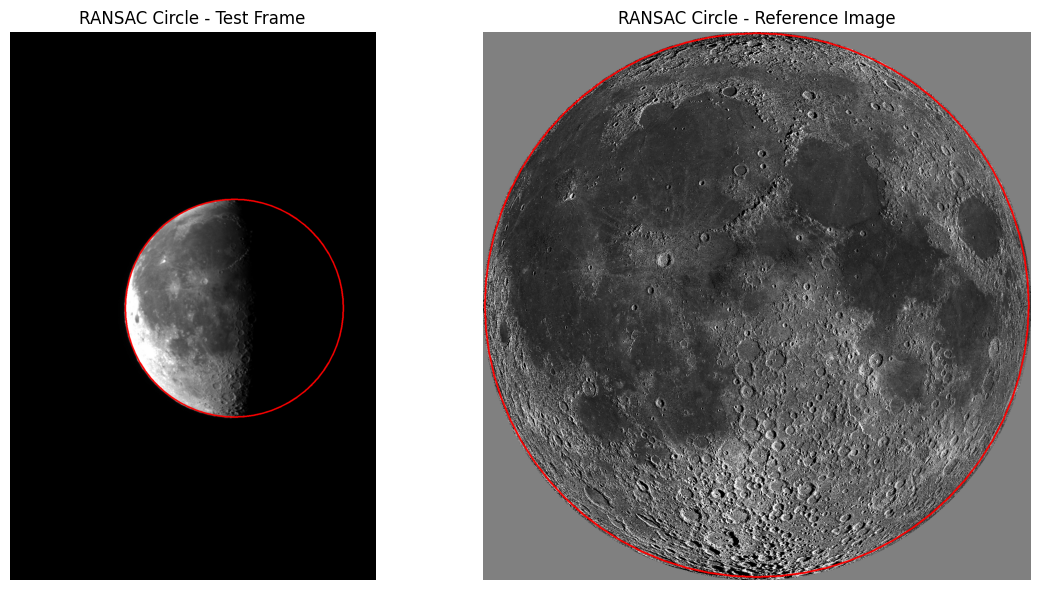

In [32]:
# drawing the fitted limb circle on each frame
test_rgb = np.ascontiguousarray(np.stack([np.clip(moon_raw[::4, ::4] / np.percentile(moon_raw, 99.5), 0, 1)] * 3, axis = -1).astype(np.float32))
cv2.circle(test_rgb, (int(test_circle[0] / 4), int(test_circle[1] / 4)), int(test_circle[2] / 4), (1, 0, 0), 3)

ref_rgb = np.ascontiguousarray(np.stack([np.clip(lroc_ref[::10, ::10] / 255.0, 0, 1)] * 3, axis = -1).astype(np.float32))
cv2.circle(ref_rgb, (int(ref_circle[0] / 10), int(ref_circle[1] / 10)), int(ref_circle[2] / 10), (1, 0, 0), 3)

fig, ax = plt.subplots(1, 2, figsize = (12, 6))
ax[0].imshow(test_rgb); ax[0].set_title('RANSAC Circle - Test Frame');      ax[0].axis('off')
ax[1].imshow(ref_rgb);  ax[1].set_title('RANSAC Circle - Reference Image'); ax[1].axis('off')
plt.tight_layout()
plt.show()

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>Scaling and Translation With RANSAC Circumference</h2>

Utilizing the circumferences of the RANSAC circles, the test frame was resized and translated to align with the reference image. This resulted in the test frame scaling by a factor of 1.425. After reviewing the overlap between the images, initial scaling and translation were both successful and are ready for fine tuning.

In [33]:
# a light square canvas for the overlap work
align_dim = 1200

ref_gray_A   = cv2.resize(src = lroc_ref,              dsize = (align_dim, align_dim), interpolation = cv2.INTER_AREA)
ref_moon_A   = cv2.resize(src = ref_moon_mask,         dsize = (align_dim, align_dim), interpolation = cv2.INTER_NEAREST)
ref_crater_A = cv2.resize(src = reference_crater_mask, dsize = (align_dim, align_dim), interpolation = cv2.INTER_NEAREST)


# reference circle re-fitted on the canvas so centre and radius are exact here
np.random.seed(random_seed)
(ref_cx_A, ref_cy_A, ref_R_A), _ = fit_limb_circle(mask = ref_moon_A)


# warping the test so its circle lands on the reference circle
scale_factor = ref_R_A / test_circle[2]

warp = cv2.getRotationMatrix2D(center = (test_circle[0], test_circle[1]), angle = 0, scale = scale_factor)
warp[0, 2] += ref_cx_A - test_circle[0]
warp[1, 2] += ref_cy_A - test_circle[1]

test_gray_A = cv2.warpAffine(src = moon_raw,       M = warp, dsize = (align_dim, align_dim), flags = cv2.INTER_LANCZOS4, borderValue = 0)
test_moon_A = cv2.warpAffine(src = test_moon_mask, M = warp, dsize = (align_dim, align_dim), flags = cv2.INTER_NEAREST,  borderValue = 0)


print(f"""
Scaled to Canvas
----------------
Canvas          : {align_dim} by {align_dim} px
Reference Circle: Center ({ref_cx_A:.0f}, {ref_cy_A:.0f})  Radius {ref_R_A:.0f} px
Scale           : {1 + scale_factor:.3f}
""")


Scaled to Canvas
----------------
Canvas          : 1200 by 1200 px
Reference Circle: Center (600, 598)  Radius 595 px
Scale           : 1.425



<br>

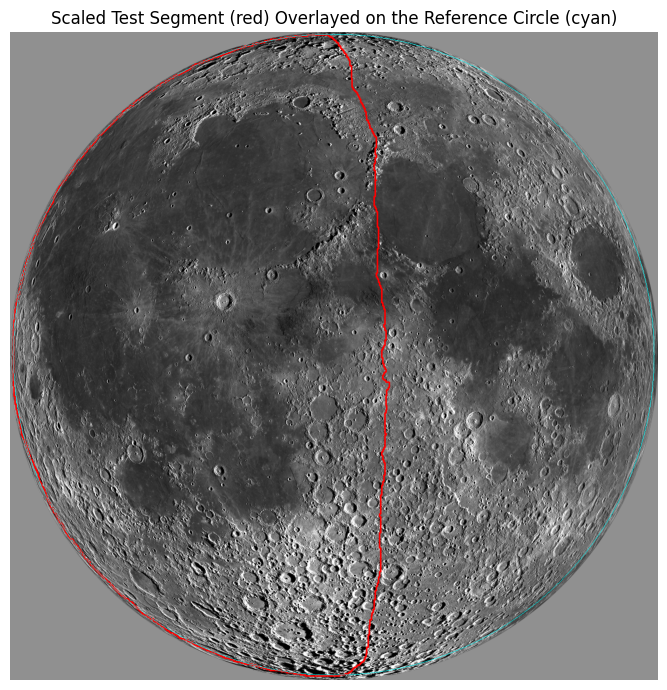

In [34]:
# scaled test outline over the reference disk, with the reference circle in cyan
canvas_rgb = np.ascontiguousarray(np.stack([np.clip(ref_gray_A / np.percentile(ref_gray_A, 99.5), 0, 1)] * 3, axis = -1).astype(np.float32))

contours, _ = cv2.findContours(test_moon_A, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(canvas_rgb, contours, -1, (1, 0, 0), 2)
cv2.circle(canvas_rgb, (int(ref_cx_A), int(ref_cy_A)), int(ref_R_A), (0, 1, 1), 1)

plt.figure(figsize = (7, 7))
plt.imshow(canvas_rgb)
plt.title('Scaled Test Segment (red) Overlayed on the Reference Circle (cyan)')
plt.axis('off')
plt.tight_layout()
plt.show()

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>Maximizing Disk Overlap</h2>

A small translation search was conducted to maximize the overlap between the two segments. An overlap of 59% would be ideal given that this was the Moon's illumination level when the test frame was captured. As can be observed from the results, the intersection over union (IoU) metric peaked at a value of 0.580, implying an illumination level of 58% (98.3% of the reference illumination level). There are also very few false positives where the test frame does not overlap with the reference image.

In [35]:
# confusion counts, iou, and dice between two binary masks
def overlap_scores(pred, truth):
    """Scores the overlap of two binary masks.

    PARAMETERS
    ----------
    pred | np.ndarray
    predicted binary mask

    truth | np.ndarray
    reference binary mask

    EXAMPLES
    --------
    overlap_scores(pred = test_moon_A, truth = ref_moon_A)\
    """

    pred  = pred.astype(bool)
    truth = truth.astype(bool)

    tp = int(( pred &  truth).sum())
    fp = int(( pred & ~truth).sum())
    fn = int((~pred &  truth).sum())
    tn = int((~pred & ~truth).sum())

    iou  = tp / (tp + fp + fn)         if (tp + fp + fn)     else 0.0
    dice = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) else 0.0

    return (tp, fp, fn, tn), iou, dice


# small translation search to maximise the disk overlap
best_shift = (0, 0)
best_iou   = -1.0

for shift_y in range(-8, 9, 2):
    for shift_x in range(-8, 9, 2):
        shifted   = np.roll(np.roll(test_moon_A, shift_y, axis = 0), shift_x, axis = 1)
        _, iou, _ = overlap_scores(pred = shifted, truth = ref_moon_A)
        if iou > best_iou:
            best_iou   = iou
            best_shift = (shift_x, shift_y)


# applying the best shift to the test grayscale and mask
shift_x, shift_y = best_shift
test_gray_A = np.roll(np.roll(test_gray_A, shift_y, axis = 0), shift_x, axis = 1)
test_moon_A = np.roll(np.roll(test_moon_A, shift_y, axis = 0), shift_x, axis = 1)

(tp, fp, fn, tn), disk_iou, disk_dice = overlap_scores(pred = test_moon_A, truth = ref_moon_A)


print(f"""
Disk Overlap
------------
Shift: dx {shift_x}, dy {shift_y}

Mask Overlap                (tp): {tp:>9}
Background Overlap          (tn): {tn:>9}
Test Frame Non-Overlap      (fp): {fp:>9}
Reference Image Non-Overlap (fn): {fn:>9}

IoU : {disk_iou:.3f}
DICE: {disk_dice:.3f}
""")


Disk Overlap
------------
Shift: dx 8, dy 0

Mask Overlap                (tp):    646589
Background Overlap          (tn):    325554
Test Frame Non-Overlap      (fp):        35
Reference Image Non-Overlap (fn):    467822

IoU : 0.580
DICE: 0.734



<br>

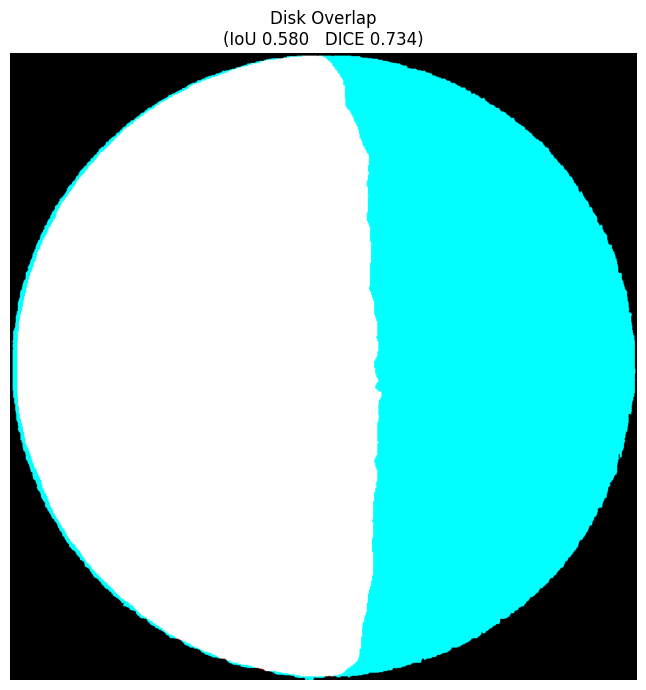

In [36]:
# red is the test disk, cyan is the reference disk, grey is agreement
composite = np.zeros((align_dim, align_dim, 3), dtype = np.float32)
composite[..., 0] = test_moon_A
composite[..., 1] = ref_moon_A
composite[..., 2] = ref_moon_A

plt.figure(figsize = (7, 7))
plt.imshow(composite)
plt.title(f"""Disk Overlap
(IoU {disk_iou:.3f}   DICE {disk_dice:.3f})""")
plt.axis('off')
plt.tight_layout()
plt.savefig("disk_overlap.png")
plt.show()

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>Centroid-Based Crater Alignment</h2>

Scale and translation have been addressed, leaving only rotation as a factor to align the images further. Thus, craters will be detected in the test segment using a non-buffered Laplacian-of-Gaussian blob detector (LoG) and evaluated against the crater reference mask. LoG is an advanced computer vision algorithm originally designed to predict circular structures, making it a strong candidate for this task. Additionally, four hyperparameters were engineered to control the number of craters being utilized for alignment, crater diameter minimums and maximums, and the crater magnification level.
<br><br>

| Hyperparameter | Description |
| --- | --- |
| `n_closest` | How many of the nearest detected craters to keep. |
| `min_diameter` | Smallest crater size allowed (in pixels). |
| `max_diameter` | Largest crater size allowed (in pixels). |
| `magnification` | Scaling factor (zoom level) applied to the view or measurements. |

<br>

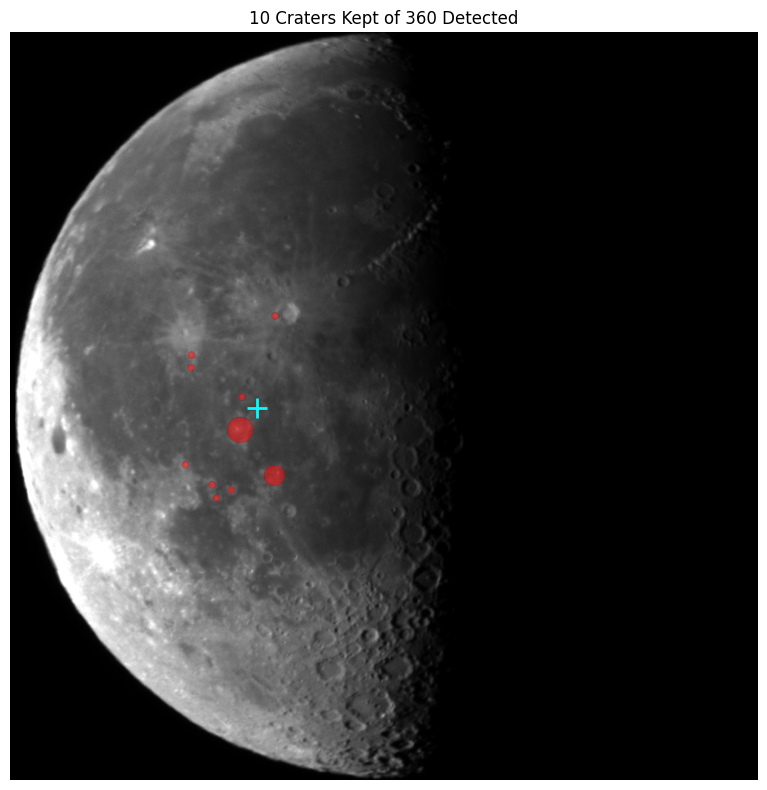

 detected_ID    lat    lon    diam_km
           0   1.72  -2.52  38.009998
           1  -3.38  -2.89 123.940002
           2 -10.48   2.48 102.459999
           3   6.26 -11.57  38.009998
           4   8.20 -11.59  38.009998
           5 -12.75  -5.01  38.009998
           6 -11.96  -8.35  38.009998
           7  -8.82 -12.90  38.009998
           8  14.38   2.38  38.009998
           9 -14.04  -7.83  38.009998


In [37]:
# how many nearest craters, the diameter band, and the draw magnification
n_closest     = 10
min_diameter  = 0.0
max_diameter  = 303.0
magnification = 1.0


# a canvas pixel to selenographic latitude and longitude, through the reference circle
def canvas_px_to_latlon(u, v):
    """maps a canvas pixel to latitude and longitude on the reference disk

    PARAMETERS
    ----------
    u, v | float
    pixel column and row on the alignment canvas

    EXAMPLES
    --------
    canvas_px_to_latlon(u = 600, v = 600)\
    """

    x = u - ref_cx_A
    y = ref_cy_A - v

    lat = math.degrees(math.asin(max(-1.0, min(1.0, y / ref_R_A))))
    lon = math.degrees(math.atan2(x, math.sqrt(max(0.0, ref_R_A**2 - x**2 - y**2))))

    return lat, lon


# detecting every crater in the segment, no buffer
test_norm = np.clip(test_gray_A / (np.percentile(test_gray_A, 99.5) + 1e-6), 0, 1)
test_8u   = cv2.bitwise_and((test_norm * 255).astype(np.uint8),
                            (test_norm * 255).astype(np.uint8),
                            mask = test_moon_A)

blobs = blob_log(test_8u.astype(np.float32) / 255.0,
                 min_sigma = 2,
                 max_sigma = 15,
                 num_sigma = 6,
                 threshold = 0.06)


# the centroid of the segment
moments    = cv2.moments(test_moon_A)
centroid_x = moments['m10'] / moments['m00']
centroid_y = moments['m01'] / moments['m00']
cen_lat, cen_lon = canvas_px_to_latlon(u = centroid_x, v = centroid_y)


# every detection, with its true diameter and its distance to the centroid
km_per_px_A = 1737.4 / ref_R_A

records = []
for b_y, b_x, b_sigma in blobs:
    b_r      = b_sigma * math.sqrt(2)
    lat, lon = canvas_px_to_latlon(u = b_x, v = b_y)
    records.append({'x_px'      : float(b_x),
                    'y_px'      : float(b_y),
                    'r_base_px' : float(b_r),
                    'lat'       : lat - cen_lat,
                    'lon'       : lon - cen_lon,
                    'diam_km'   : 2.0 * b_r * km_per_px_A,
                    'dist'      : math.hypot(b_x - centroid_x, b_y - centroid_y)})

all_detections = pd.DataFrame(records)


# applying the four controls: diameter band, then nearest-n, then a magnified draw radius
def build_detected(n_keep, min_km, max_km, magnify):
    """Selects and sizes detections from the four hyperparameters.

    PARAMETERS
    ----------
    n_keep | int
    how many nearest-to-centroid detections to keep

    min_km, max_km | float
    diameter band in kilometres

    magnify | float
    multiplier on each crater's drawn radius

    EXAMPLES
    --------
    build_detected(n_keep = 10, min_km = 0, max_km = 300, magnify = 2)\
    """

    kept = all_detections[(all_detections['diam_km'] >= min_km) &
                          (all_detections['diam_km'] <= max_km)].copy()
    kept = kept.sort_values('dist').head(n_keep).reset_index(drop = True)
    kept['r_px'] = kept['r_base_px'] * magnify
    kept.insert(0, 'detected_ID', kept.index)

    return kept[['detected_ID', 'x_px', 'y_px', 'r_px', 'lat', 'lon', 'diam_km']]


# painting a crater dataframe into a binary mask on the canvas
def craters_to_mask(frame):
    """Paints a crater dataframe into a binary mask on the canvas.

    PARAMETERS
    ----------
    frame | pd.DataFrame
    craters with x_px, y_px, r_px columns

    EXAMPLES
    --------
    craters_to_mask(frame = detected_craters)\
    """

    mask = np.zeros((align_dim, align_dim), dtype = np.uint8)
    for _, crater in frame.iterrows():
        cv2.circle(img       = mask,
                   center    = (int(crater['x_px']), int(crater['y_px'])),
                   radius    = max(2, int(crater['r_px'])),
                   color     = 1,
                   thickness = -1)
    return (mask & test_moon_A).astype(np.uint8)


detected_craters = build_detected(n_keep = n_closest, min_km = min_diameter, max_km = max_diameter, magnify = magnification)
test_crater_mask = craters_to_mask(frame = detected_craters)


# a stable snapshot of the centroid-step detections, used later during review
centroid_craters = detected_craters.copy()


# plotting the centroid and the kept craters, then saving
plt.figure(figsize = (8, 8))
plt.imshow(test_norm, cmap = 'gray')
plt.imshow(np.ma.masked_where(test_crater_mask == 0, test_crater_mask), cmap = 'autumn', alpha = 0.5)
plt.scatter([centroid_x], [centroid_y], marker = '+', s = 220, c = 'cyan', linewidths = 2)
plt.title(f'{len(detected_craters)} Craters Kept of {len(blobs)} Detected')
plt.axis('off')
plt.tight_layout()

plt.savefig('moon_segment_crater_predictions.png', dpi = 120)
plt.show()

print(detected_craters[['detected_ID', 'lat', 'lon', 'diam_km']].round(2).to_string(index = False))

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>Tuning Crater Alignment</h2>

The four crater alignment hyperparameters were tuned using a Bayesian approach, optimizing the DICE coefficient. Across 500 trials, DICE peaked at 0.859, favoring craters with diameters between 90 and 120 kilometers at a magnification level of 3.0. The ideal number of craters was varied substantially amongst the leading tuning trials, ranging from 21 to 68.
<br><br>
The tuning results imply that large craters at a high magnification level are preferred. In other words, alignment works well when segmentation mask surfaces are reasonably large.

In [38]:
# # baseline establishment (DICE 0.037)
# n_closest_grid     = np.arange(295, 297, 1)
# min_diameter_grid  = np.arange(0, 1, 1)
# max_diameter_grid  = np.arange(350, 400, 25)
# magnification_grid = np.arange(1.00, 1.01, .10)
# tuning_trials      = 2

# hyperparameter tuning
n_closest_grid     = np.arange(1, 11, 1)
min_diameter_grid  = np.arange(0, 101, 25)
max_diameter_grid  = np.arange(50, 301, 25)
magnification_grid = np.arange(1.00, 2.01, .10)
tuning_trials      = 500


# projecting the mare catalog craters onto the canvas, the alignment target
def canvas_latlon_to_px(lat_deg, lon_deg):
    """Maps latitude and longitude to a canvas pixel on the reference disk.

    PARAMETERS
    ----------
    lat_deg, lon_deg | float
    latitude north and longitude east, in degrees

    EXAMPLES
    --------
    canvas_latlon_to_px(lat_deg = 9.62, lon_deg = -20.07)\
    """

    lat = np.radians(lat_deg)
    lon = np.radians(lon_deg)

    return ref_cx_A + ref_R_A * np.cos(lat) * np.sin(lon), ref_cy_A - ref_R_A * np.sin(lat)


catalog_u, catalog_v = canvas_latlon_to_px(lat_deg = visible['lat'].values, lon_deg = visible['lon'].values)
catalog_r            = np.maximum(2.0, (visible['diam_km'].values / 2.0) / km_per_px_A)


# painting equal disks, reference sized to match its test crater, so the score reflects position
def crater_disks(x_values, y_values, r_values):
    """Paints craters as filled disks on the canvas.

    PARAMETERS
    ----------
    x_values, y_values, r_values | iterable
    centres and radii in canvas pixels

    EXAMPLES
    --------
    crater_disks([600], [600], [10])\
    """

    mask = np.zeros((align_dim, align_dim), dtype = np.uint8)
    for x_c, y_c, r_c in zip(x_values, y_values, r_values):
        cv2.circle(img = mask, center = (int(x_c), int(y_c)), radius = max(2, int(r_c)), color = 1, thickness = -1)
    return mask


# matching a crater set to the catalog at each rotation, then the best crater DICE
def align_score(craters, search_deg = 30.0, step_deg = 2.0):
    """Matches detected craters to the catalog and scores their overlap.

    PARAMETERS
    ----------
    craters | pd.DataFrame
    detected craters with x_px, y_px, r_px columns

    search_deg | float
    half-width of the rotation window in degrees

    step_deg | float
    rotation step in degrees

    EXAMPLES
    --------
    align_score(craters = detected_craters, step_deg = 0.5)\
    """

    blank = np.zeros((align_dim, align_dim), dtype = np.uint8)

    if len(craters) < 2:
        return {'n_matched': 0, 'init_iou': 0.0, 'init_dice': 0.0, 'opt_iou': 0.0,
                'opt_dice': 0.0, 'best_angle': 0.0, 'test_mask': blank, 'ref_mask': blank, 'test_rot': blank}

    test_r = craters['r_px'].values


    # rotating the crater centres about the disk centre by a given angle
    def rotate_points(angle):
        theta = math.radians(angle)
        dx    = craters['x_px'].values - ref_cx_A
        dy    = craters['y_px'].values - ref_cy_A
        px    = ref_cx_A + dx * math.cos(theta) - dy * math.sin(theta)
        py    = ref_cy_A + dx * math.sin(theta) + dy * math.cos(theta)
        return px, py


    # matching every rotated crater to its nearest unused catalog crater, then the disk dice
    def score_at(angle):
        px, py  = rotate_points(angle = angle)
        taken   = set()
        test_cx = []; test_cy = []; test_cr = []
        ref_cx  = []; ref_cy  = []; ref_cr  = []

        for k in range(len(px)):
            gaps  = np.hypot(catalog_u - px[k], catalog_v - py[k])
            order = np.argsort(gaps)

            nearest = -1
            for j in order:
                if int(j) not in taken:
                    nearest = int(j)
                    break

            if nearest < 0:
                continue

            taken.add(nearest)
            test_cx.append(px[k]);             test_cy.append(py[k]);             test_cr.append(test_r[k])
            ref_cx.append(catalog_u[nearest]); ref_cy.append(catalog_v[nearest]); ref_cr.append(test_r[k])

        if len(test_cx) < 2:
            return 0.0, 0.0, blank, blank, 0

        test_mask = crater_disks(test_cx, test_cy, test_cr)
        ref_mask  = crater_disks(ref_cx,  ref_cy,  ref_cr)
        _, iou, dice = overlap_scores(pred = test_mask, truth = ref_mask)

        return iou, dice, test_mask, ref_mask, len(test_cx)


    # the un-rotated baseline, then the strongest angle across the search window
    init_iou, init_dice, init_test, init_ref, init_n = score_at(angle = 0.0)

    best_angle = 0.0
    best_iou   = init_iou
    best_dice  = init_dice
    best_test  = init_test
    best_ref   = init_ref
    best_n     = init_n

    for angle in np.arange(-search_deg, search_deg + step_deg, step_deg):
        iou, dice, test_mask, ref_mask, n_at = score_at(angle = angle)
        if dice > best_dice:
            best_angle = angle
            best_iou   = iou
            best_dice  = dice
            best_test  = test_mask
            best_ref   = ref_mask
            best_n     = n_at

    return {'n_matched': best_n, 'init_iou': init_iou, 'init_dice': init_dice, 'opt_iou': best_iou,
            'opt_dice': best_dice, 'best_angle': best_angle, 'test_mask': init_test, 'ref_mask': best_ref, 'test_rot': best_test}


# one optuna trial: sample the four controls, build that set, and return its best DICE
def objective(trial):
    """Scores one hyperparameter draw by its best crater DICE.

    PARAMETERS
    ----------
    trial | optuna.Trial
    the trial that proposes the four controls

    EXAMPLES
    --------
    study.optimize(objective, n_trials = 100)\
    """

    n_keep  = trial.suggest_int(name = 'n_closest',    low = int(n_closest_grid.min()),    high = int(n_closest_grid.max()))
    min_km  = trial.suggest_int(name = 'min_diameter', low = int(min_diameter_grid.min()), high = int(min_diameter_grid.max()), step = 10)
    max_km  = trial.suggest_int(name = 'max_diameter', low = int(max_diameter_grid.min()), high = int(max_diameter_grid.max()), step = 10)
    magnify = trial.suggest_float(name = 'magnification', low = round(float(magnification_grid.min()), 2), high = round(float(magnification_grid.max()), 2), step = 0.1)

    # skipping configurations already evaluated, returning the earlier score
    for prior in trial.study.trials:
        if prior.state == optuna.trial.TrialState.COMPLETE and prior.params == trial.params:
            return prior.value

    if min_km >= max_km:
        return 0.0

    trial_craters = build_detected(n_keep = n_keep, min_km = min_km, max_km = max_km, magnify = magnify)
    return align_score(craters = trial_craters, step_deg = 2.0)['opt_dice']


# running the study quietly and reproducibly for one hundred trials
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(direction = 'maximize',
                            sampler   = optuna.samplers.TPESampler(seed = random_seed))
study.optimize(objective, n_trials = tuning_trials, show_progress_bar = False)


# ranking every trial by dice, then breaking ties by fewest craters, then tightest floor
ranked = study.trials_dataframe(attrs = ('value', 'params'))
ranked = ranked.sort_values(by        = ['value', 'params_n_closest', 'params_min_diameter'],
                            ascending = [False,    True,               False]).reset_index(drop = True)


# keeping one row per unique configuration
ranked = ranked.drop_duplicates(subset = ['params_n_closest',
                                          'params_min_diameter',
                                          'params_max_diameter',
                                          'params_magnification']).reset_index(drop = True)


# adopting the best row and rebuilding the detections with it
best          = ranked.iloc[0]
n_closest     = int(best['params_n_closest'])
min_diameter  = float(best['params_min_diameter'])
max_diameter  = float(best['params_max_diameter'])
magnification = float(best['params_magnification'])

detected_craters = build_detected(n_keep = n_closest, min_km = min_diameter, max_km = max_diameter, magnify = magnification)
test_crater_mask = craters_to_mask(frame = detected_craters)


# a stable snapshot of the tuning-step detections, used later during review
tuned_craters = detected_craters.copy()


print(f"""
Optuna Tuning
-------------
Trials       : {len(study.trials)}
Best DICE    : {best['value']:.3f}
n_closest    : {n_closest}
min_diameter : {min_diameter:.0f} km
max_diameter : {max_diameter:.0f} km
magnification: {magnification:.1f}
""")


# the strongest trials, ties broken by fewest craters then tightest floor
print(ranked.head(n = 10).to_string(index = False))


Optuna Tuning
-------------
Trials       : 500
Best DICE    : 0.898
n_closest    : 2
min_diameter : 30 km
max_diameter : 230 km
magnification: 2.0

  value  params_magnification  params_max_diameter  params_min_diameter  params_n_closest
0.89828                   2.0                  230                   30                 2
0.89828                   2.0                  260                   30                 2
0.89828                   2.0                  140                   30                 2
0.89828                   2.0                  250                   30                 2
0.89828                   2.0                  160                   30                 2
0.89828                   2.0                  270                   30                 2
0.89828                   2.0                  150                   30                 2
0.89828                   2.0                  260                   20                 2
0.89828                   2.0            

<br>

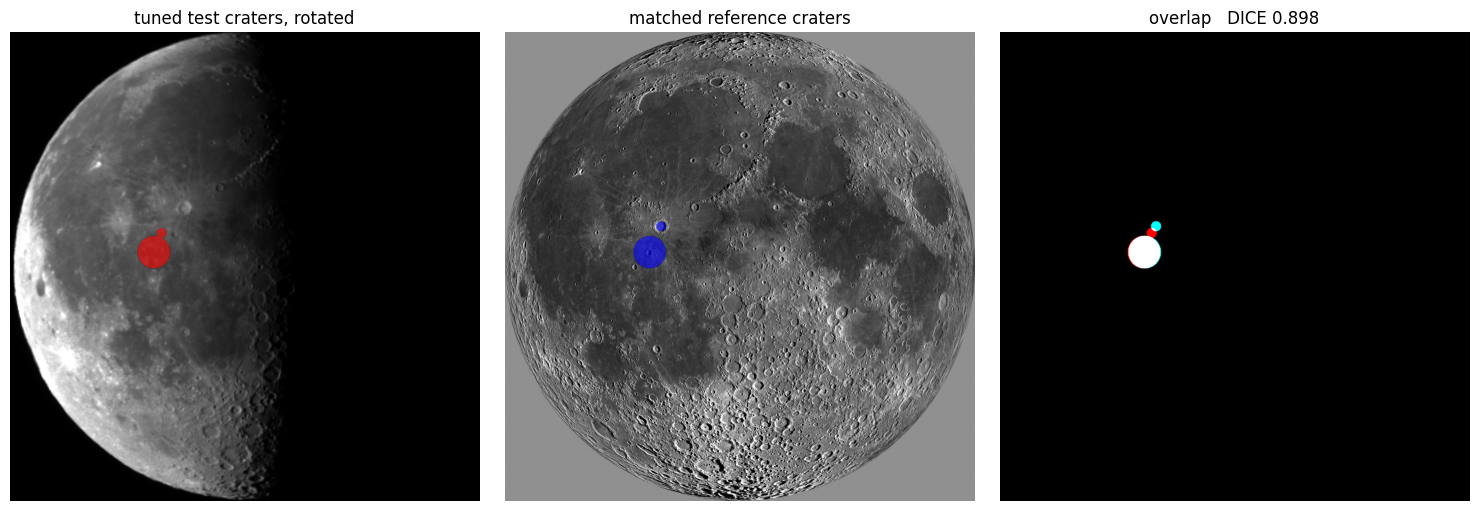

In [39]:
# the best tuning configuration scored and rotated for display
tuned_result   = align_score(craters = detected_craters, search_deg = 30.0, step_deg = 2.0)
test_norm_disp = np.clip(test_gray_A / (np.percentile(test_gray_A, 99.5) + 1e-6), 0, 1)
ref_norm_disp  = np.clip(ref_gray_A  / (np.percentile(ref_gray_A,  99.5) + 1e-6), 0, 1)


# tuned test craters, matched reference craters, and their overlap at the best angle
fig, ax = plt.subplots(1, 3, figsize = (15, 5))

ax[0].imshow(test_norm_disp, cmap = 'gray')
ax[0].imshow(np.ma.masked_where(tuned_result['test_rot'] == 0, tuned_result['test_rot']), cmap = 'autumn', alpha = 0.6)
ax[0].set_title('tuned test craters, rotated'); ax[0].axis('off')

ax[1].imshow(ref_norm_disp, cmap = 'gray')
ax[1].imshow(np.ma.masked_where(tuned_result['ref_mask'] == 0, tuned_result['ref_mask']), cmap = 'winter', alpha = 0.6)
ax[1].set_title('matched reference craters'); ax[1].axis('off')

overlap = np.zeros((align_dim, align_dim, 3), dtype = np.float32)
overlap[..., 0] = tuned_result['test_rot']
overlap[..., 1] = tuned_result['ref_mask']
overlap[..., 2] = tuned_result['ref_mask']
ax[2].imshow(overlap); ax[2].set_title(f"overlap   DICE {tuned_result['opt_dice']:.3f}"); ax[2].axis('off')

plt.tight_layout()
plt.savefig('tuning_best_alignment.png', dpi = 120)
plt.show()


<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>Removing False Positives</h2>

False positives can be filtered out manually. Doing so will rewrite the set detected craters and rebuild the crater mask.

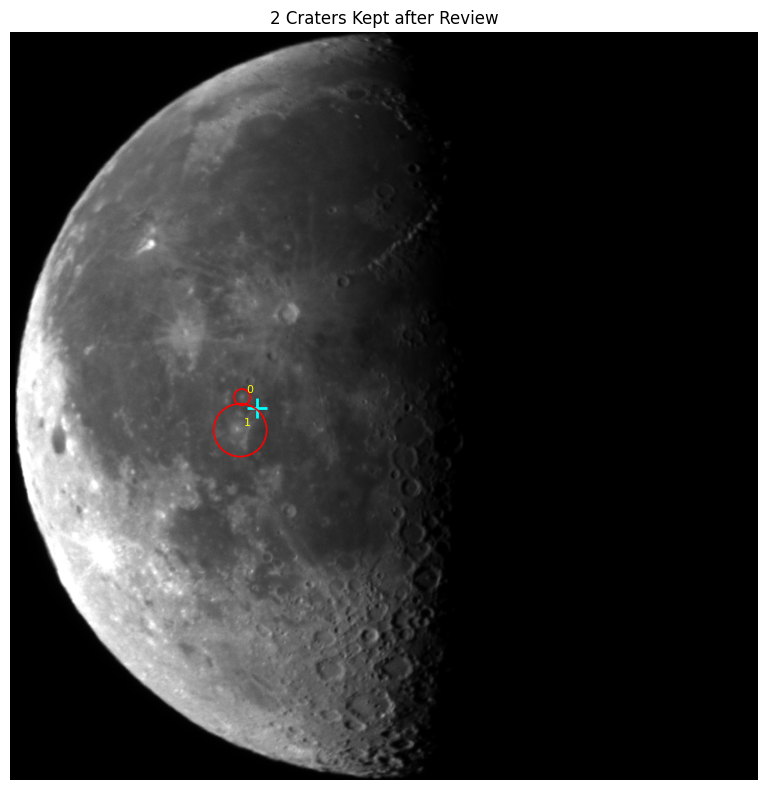


Reviewed Craters
----------------
Dropped: []
Kept   : 2



In [40]:
# detected_ID values to treat as false positives, edit and re-run to iterate
false_positive_ids = []


# the craters detected in the centroid step or the tuning step, keyed by canvas position
detected_universe = pd.concat([centroid_craters, tuned_craters], ignore_index = True)
detected_keys     = set(zip(detected_universe['x_px'].round(3), detected_universe['y_px'].round(3)))


# reviewing the stable tuning-step detections, keeping only genuine detections, then dropping the flagged ids
craters_reviewed = tuned_craters.copy()
craters_reviewed = craters_reviewed[[(x, y) in detected_keys
                                     for x, y in zip(craters_reviewed['x_px'].round(3),
                                                     craters_reviewed['y_px'].round(3))]].reset_index(drop = True)
craters_reviewed = craters_reviewed[~craters_reviewed['detected_ID'].isin(false_positive_ids)].reset_index(drop = True)


# visualising the kept craters with their ids so they can be fine tuned
plt.figure(figsize = (8, 8))
plt.imshow(test_norm, cmap = 'gray')
plt.scatter([centroid_x], [centroid_y], marker = '+', s = 220, c = 'cyan', linewidths = 2)

for _, crater in craters_reviewed.iterrows():
    circle = plt.Circle((crater['x_px'], crater['y_px']), max(3, crater['r_px']),
                        color = 'red', fill = False, linewidth = 1.2)
    plt.gca().add_patch(circle)
    plt.text(crater['x_px'] + 6, crater['y_px'] - 6, str(int(crater['detected_ID'])),
             color = 'yellow', fontsize = 8)

plt.title(f'{len(craters_reviewed)} Craters Kept after Review')
plt.axis('off')
plt.tight_layout()
plt.savefig('moon_segment_crater_predictions.png', dpi = 120)
plt.show()


# saving back under the original name and rebuilding the mask for the pipeline
detected_craters = craters_reviewed
test_crater_mask = craters_to_mask(frame = detected_craters)

print(f"""
Reviewed Craters
----------------
Dropped: {false_positive_ids}
Kept   : {len(detected_craters)}
""")

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>Matching Craters and Optimizing DICE</h2>

The segments are already well aligned, making rotation a small refinement. Tuning in this stage was also based on maximizing the DICE coefficient. After implementing an ideal rotation of 18.4 degrees, the DICE coefficient exhibited its highest value of 0.909.

In [41]:
# final matched alignment on the tuned and reviewed craters, using a fine rotation step
result   = align_score(craters = detected_craters, search_deg = 30.0, step_deg = 0.05)
ref_norm = np.clip(ref_gray_A / (np.percentile(ref_gray_A, 99.5) + 1e-6), 0, 1).astype(np.float32)


print(f"""
Crater Overlap
--------------
Matched  : {result['n_matched']}
Rotation : {result['best_angle']:.1f} deg
              Initial   Optimised
IoU      : {result['init_iou']:>8.3f}   {result['opt_iou']:>8.3f}
DICE     : {result['init_dice']:>8.3f}   {result['opt_dice']:>8.3f}
""")


Crater Overlap
--------------
Matched  : 2
Rotation : 18.4 deg
              Initial   Optimised
IoU      :    0.495      0.833
DICE     :    0.663      0.909



<br>

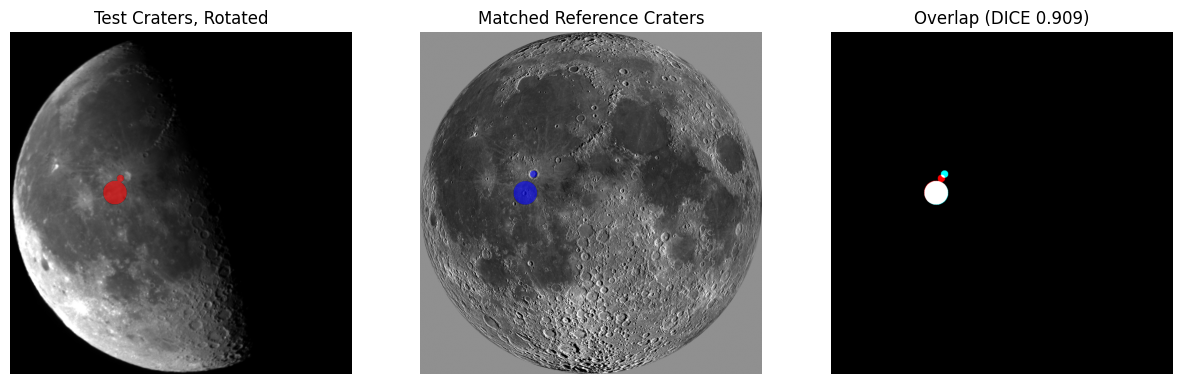

In [42]:
# applying the solved rotation to the aligned frame
spin         = cv2.getRotationMatrix2D(center = (ref_cx_A, ref_cy_A), angle = result['best_angle'], scale = 1.0)
test_aligned = cv2.warpAffine(test_gray_A, spin, (align_dim, align_dim), flags = cv2.INTER_LANCZOS4)

test_aligned_norm = np.clip(test_aligned / (np.percentile(test_aligned, 99.5) + 1e-6), 0, 1)


# side by side and overlap, after the rotation
fig, ax = plt.subplots(1, 3, figsize = (15, 5))

ax[0].imshow(test_aligned_norm, cmap = 'gray')
ax[0].imshow(np.ma.masked_where(result['test_rot'] == 0, result['test_rot']), cmap = 'autumn', alpha = 0.6)
ax[0].set_title('Test Craters, Rotated'); ax[0].axis('off')

ax[1].imshow(ref_norm, cmap = 'gray')
ax[1].imshow(np.ma.masked_where(result['ref_mask'] == 0, result['ref_mask']), cmap = 'winter', alpha = 0.6)
ax[1].set_title('Matched Reference Craters'); ax[1].axis('off')

overlap = np.zeros((align_dim, align_dim, 3), dtype = np.float32)
overlap[..., 0] = result['test_rot']
overlap[..., 1] = result['ref_mask']
overlap[..., 2] = result['ref_mask']
ax[2].imshow(overlap); ax[2].set_title(f'Overlap (DICE {result["opt_dice"]:.3f})'); ax[2].axis('off')

#plt.tight_layout()
plt.savefig("final_crater_alignment.png")
plt.show()

<br>

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>Reflection</h2>

Astrophotography comes with a steep learning curve spanning several steps, including camera/telescope configuration, celestial object detection, capturing focused and stable frames, frame alignment, lucky imaging, and post-processing techniques such as wavelet sharpening. Frame alignment is the first step post-capture step, and this project has introduced a highly automated pipeline specifically designed for aligning frames of the Moon. The pipeline advances beyond existing techniques such as global stabilization and automatic grandient-based local alignment based on image gradients, utilizing modern computer vision techniques such as SAM and LoG in a practical manner.
<br><br>
A future project is being considered for lucky imaging and wavelet sharpening, expanding the post-capture pipeline into an end-to-end solution so that astrophotographers can focus their efforts on detecting and capturing celestial objects.

<h4>Key Learnings</h4>
This project has explored several computer vision approaches and has evolved across countless iterations. The key learnings below are offered to anyone endeavoring to develop on its foundation.

<ul>
<li>The orthographic fold hides on the limb. Early crater maps leaked far-side craters onto the near side. The cause was the projection, not the longitude filter. A near-side crater and its far-side twin land on the same pixel. An emission-angle cap and the mare bounding boxes helped alleviate this problem.</li>
<li>SAM needs the right prompt. A single centre point segmented the reference at 0.2% of the frame, latching onto one crater. A box prompt over the disk with a geometric fallback brought SAM from a reference segment makeup 0.2% to 77.4%.</li>
<li>A DeepMoon U-Net transfer learning approach did not lead to strong segmentation. Binary segmentation mask development with SAM performed much better at a fraction of the compute time.</li>

<br>